# Library Import

In [1]:
import matplotlib.pyplot as plt

import numpy as np
# NiBabel suggests to clamp the precision of np arrays to 2 decimal digits
np.set_printoptions(precision=2, suppress=True)

from torch.utils.data import random_split
import torch
from torch.utils.data import Dataset

import sys
import re
import os
from sh import gunzip # Save the MRI Images after Skull-Removal Pre-Processing

import pandas as pd

import albumentations

from PIL import Image

from tqdm import tqdm
from pprint import pprint

import json

print("Libraries imported")

Libraries imported


In [83]:
DEVICE = "mps"

elem_1 = torch.randn(size=(100,80,100), dtype=torch.float, device=DEVICE)
# elem_1 = torch.tensor([[[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]],
#                         [[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]],
#                         [[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]],
#                         [[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]],
#                         [[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]],
#                         [[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]]], dtype=torch.float, device=DEVICE)
elem_2 = torch.randn(size=(100,80,100), dtype=torch.float, device=DEVICE)
# elem_2 = torch.tensor([[[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]],
#                        [[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]],
#                        [[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]],
#                        [[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]],
#                        [[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]],
#                        [[0.1, 0.2, 0.3, 0.4, 0.5], [0.1, 0.2, 0.3, 0.4, 0.5]]], dtype=torch.float, device=DEVICE)

#print(elem_1);
print(elem_1.shape)
#print(elem_2);
print(elem_2.shape)

# print(elem_1[:,elem_1.shape[1]//2, elem_1.shape[2]//2])


sim = torch.cosine_similarity(elem_1, elem_2) #torch.reshape(elem_2, shape=(elem_1.shape[0], elem_1.shape[1], -1)))
sim = torch.flatten(sim)
print(sim); print(sim.shape)
similarity = torch.prod(sim)
print("Similarity: ", similarity)

torch.Size([100, 80, 100])
torch.Size([100, 80, 100])
tensor([-0.0166, -0.0280, -0.0894,  ..., -0.1430,  0.1926,  0.0116],
       device='mps:0')
torch.Size([10000])
Similarity:  tensor(0., device='mps:0')


# Other Usefull Experimental Libraries

In [2]:
import SimpleITK as sitk # Similar to NiBabel API It's a Python package for reading and writing Neuroimaging Data (files NIfTIs)

from dltk.io import preprocessing
from dltk.io import augmentation

from skimage import filters

from nipype.interfaces import fsl # Skull-Stripping

import cv2

print("Other Libraries imported")

Other Libraries imported


# Pre-Processing Functions

In [3]:
def resample_img(itk_image, out_spacing=[2.0, 2.0, 2.0]):
    ''' This function resamples images to 2-mm isotropic voxels. 
        Parameters:
            itk_image -- Image in simpleitk format, not a numpy array
            out_spacing -- Space representation of each voxel        
        Returns: 
            Resulting image in simpleitk format, not a numpy array
    '''
    
    # Resample images to 2mm spacing with SimpleITK
    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
                int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
                int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(itk_image.GetDirection())
    resample.SetOutputOrigin(itk_image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(itk_image.GetPixelIDValue())

    resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(itk_image)

def skull_strip_nii(original_img, destination_img, frac=0.3):
    ''' Practice skull stripping on the given image, and save
        the result to a new .nii image.
        Uses FSL-BET 
        (https://fsl.fmrib.ox.ac.uk/fsl/fslwiki/BET/UserGuide#Main_bet2_options:)
        
        Parameters:
            original_img -- Original nii image
            destination_img -- The new skull-stripped image
            frac -- Fractional intensity threshold for BET
    '''
    
    btr = fsl.BET()
    btr.inputs.in_file = original_img
    btr.inputs.frac = frac
    btr.inputs.out_file = destination_img
    btr.cmdline
    res = btr.run()

# Image Resizing

In [4]:
def resize_image_with_crop_or_pad(image, img_size=(64, 64, 64), **kwargs):
    """Image resizing. Resizes image by cropping or padding dimension
     to fit specified size.

    Args:
        image (np.ndarray): image to be resized
        img_size (list or tuple): new image size
        kwargs (): additional arguments to be passed to np.pad

    Returns:
        np.ndarray: resized image
    """

    assert isinstance(image, (np.ndarray, np.generic))
    assert (image.ndim - 1 == len(img_size) or image.ndim == len(img_size)), \
        'Example size doesnt fit image size'

    # Convert image to Tensor to avoid problem with np.pad() function (ValueError on slicing procedure)
    image = torch.tensor(image)
    
    # Get the image dimensionality
    rank = len(img_size)

    # Create placeholders for the new shape
    from_indices = [[0, image.shape[dim]] for dim in range(rank)]
    to_padding = [[0, 0] for dim in range(rank)]

    slicer = [slice(None)] * rank

    # For each dimensions find whether it is supposed to be cropped or padded
    for i in range(rank):
        if image.shape[i] < img_size[i]:
            to_padding[i][0] = (img_size[i] - image.shape[i]) // 2
            to_padding[i][1] = img_size[i] - image.shape[i] - to_padding[i][0]
        else:
            from_indices[i][0] = int(np.floor((image.shape[i] - img_size[i]) / 2.))
            from_indices[i][1] = from_indices[i][0] + img_size[i]

        # Create slicer object to crop or leave each dimension
        slicer[i] = slice(from_indices[i][0], from_indices[i][1])

    # Pad the cropped image to extend the missing dimension
    return np.pad(image[slicer], to_padding, **kwargs)

# Utility Function for Data JSOn Creation

## Navigate folders

In [5]:
def navigate_folders(path:str, lst:list):
        if os.path.isfile(path) and ".nii" in path: # Base case: I've reached the file itself
            id_img = re.split("/", os.path.abspath(path))[-2]
            id_patient = re.split("/", os.path.abspath(path))[-5]
            visit_date = re.findall(r"([0-9]+-[0-9]+-[0-9]+)", re.split("/", os.path.abspath(path))[-3])[0]

            # Looks if a patient has two MRI referred to the same visit (scaled/scaled_2)
            already_in_lst = False
            for tup in lst:
                if tup[:2] == (id_patient, visit_date): already_in_lst=True; break
            if already_in_lst==False: lst.append((id_patient, id_img, path)) # We take into account just scaled .nii files
            # else: print(f"- Already inside the list: {path}")

            return lst
        else:
            sub_dir=sorted(os.listdir(path)) #; print(sub_dir)
            if ".DS_Store" in sub_dir: sub_dir.remove(".DS_Store") ## Avoiding hidden files in MAC OS
            for dir in sub_dir:
                # print(dir)
                if ".csv" in dir: continue
                lst = navigate_folders(os.path.join(path, dir), lst)
        return lst

## Inspect patients

In [6]:
def inspect_patiens(data_path:str=None, img_dir:str=None, patient_dict:dict=None, process_desc:str=None):
    df = pd.read_csv(data_path)
    dict_row = {} if patient_dict == None else patient_dict
    
    list_path = navigate_folders(path=img_dir, lst=[])
    with tqdm(range(len(df)), desc=process_desc) as pbar:
        for i, row in zip(pbar, df.index):
            # if i < 30:
            row = df.loc[row] # <class 'pandas.core.series.Series'>
            subject = row["Subject"]
            last_age = []
            for path_row in list_path:
                if path_row[0] == subject:
                    if path_row[1] == row["Image Data ID"]:
                        img_path = path_row[2]
                        if not "Scaled_2" in row["Description"]: # If the image is not "Scaled_2"
                            value = {"sex": row["Sex"],
                                    "age": str(row["Age"]),
                                    "visit": row["Visit"],
                                    "group": row["Group"],
                                    "date": row["Acq Date"],
                                    "img_id": row["Image Data ID"],
                                    "img_path": img_path}
                            if subject in dict_row.keys():
                                # print("Paziente già presente")
                                if value in dict_row[subject]: continue; print(dict_row[subject])
                                for elem in dict_row[subject]:
                                    if value["age"] in elem["age"]: break; # print(elem); break
                                else: dict_row.setdefault(subject,[]).append(value); last_age.append(value["age"])
                            else:
                                # if value["age"] in last_age: continue
                                # else:
                                dict_row.setdefault(subject,[]).append(value); last_age.append(value["age"])
                            pbar.set_postfix({"ROW":i, "PAT": subject, "TOT_PATIENT": len(dict_row)})
                            pbar.update()
                    else: continue
                else: continue

    return dict_row

# MRI Dataset (Dataset Class Corrected)

## Buona

In [22]:
class MRIDataset(Dataset):
    def __init__(self, metadata_json:str=None, img_zize:list=[181,217,181]):
        if metadata_json == None: print("You're not providing a path to JSON Metadata File")
        else:
            self.dataset = []
            self.levelDisease = {'CN':0, 'MCI':1, 'AD':2} # Chiave numerica e non stringa per la NN
            self.whitening = False

            self.create(metadata_json, img_zize)
            print("-- Dataset Creation Completed --")

    def create(self, metadata_json, img_size):
        with open(file=metadata_json, mode="r") as infile: content = json.load(infile)
        with tqdm(range(len(content))) as pbar:
            for i, key, val in zip(pbar, content.keys(), content.values()):
                for j in range(len(val)):
                    if os.path.exists(val[j]["img_path"]) == False: print(f"La directory {val[j]['img_path']} non esiste"); continue
                    else:
                        # Load Image in SIKT format
                        t1_img = sitk.ReadImage(val[j]["img_path"])
                        # Transform Image into a Numpy Array
                        t1_img = resample_img(t1_img)
                        img = sitk.GetArrayFromImage(t1_img)

                        # Normalise the image to fit [-1, 1] range:
                        # norm_img = preprocessing.normalise_one_one(img)

                        # Normalise the image to fit [0, 1] range:
                        norm_img = preprocessing.normalise_zero_one(img)

                        # Crop or Pad (with optionally thresholding to black and white)
                        if self.whitening == True:
                            otsu = filters.threshold_otsu(norm_img)
                            otsu_img = norm_img > otsu
                            img = resize_image_with_crop_or_pad(image=otsu_img, img_size=img_size, mode='edge') # Crop or Pad
                        else: img = resize_image_with_crop_or_pad(image=norm_img, img_size=img_size, mode='edge') # Crop or Pad

                        if img.size == 0: print("Error: There's an empty image container")
                        
                        # Add dimention corresponding to "Channel"
                        img = np.expand_dims(img, axis=0) # channel dimension (then accordingly with Conv3D input to NN would be ([batch],channels,depth,height,width)

                        try:
                            item = {}
                            item['Subject'] = key
                            item['idImage'] = val[j]["img_id"]
                            item['Age'] = val[j]["age"]
                            item['Sex'] = [0] if val[j]["sex"] == 'M' else [1]
                            item['Visit'] = val[j]["date"]
                            item['ADType'] = list([0,0,0]); item['ADType'][self.levelDisease[val[j]['group']]] = 1
                            item['Image'] = img # casted_img #img

                            # if not any(diz['idImage'] == img_id and diz['Subject'] == p for diz in self.dataset): 
                            self.dataset.append(item)
                            pbar.set_postfix(FILE= key)
                            pbar.update()
                            # else:
                            #    # print('item with idImage {} related to visit {} is already in the dataset'.format(item['idImage'],item['Visit']))
                            #    pbar.set_postfix(FILE=re.split("/", fileName)[-1],
                            #                    MSG=f"Item: (idImage:{item['idImage']}, visit:{item['Visit']}) is already in the Dataset")
                            #    pbar.update(0)
                        except: print("Error: It has occurred an error while creating the dataset")
           
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

## Correzione

In [115]:
class MRIDataset(Dataset):
    def __init__(self, metadata_json:str=None, img_zize:list=[181,217,181]):
        if metadata_json == None: print("You're not providing a path to JSON Metadata File")
        else:
            self.dataset = []
            self.levelDisease = {'CN':0, 'MCI':1, 'AD':2} # Chiave numerica e non stringa per la NN
            self.whitening = False

            self.create(metadata_json, img_zize)
            print("-- Dataset Creation Completed --")

    def create(self, metadata_json, img_size):
        with open(file=metadata_json, mode="r") as infile: content = json.load(infile)
        with tqdm(range(len(content))) as pbar:
            for i, key, val in zip(pbar, content.keys(), content.values()):
                counter = 0
                for j in range(len(val)): 
                    # Since the mental status remains constant during the monitoring we take only the screening img
                    # Just in case disorder="AD" we take the all monitoring history for that patient
                        # This is done to add more Alzhimer samples.
                    if val[j]["group"] != "AD":
                        if os.path.exists(val[j]["img_path"]) == False: print(f"La directory {val[j]['img_path']} non esiste"); continue
                        else:
                            # Apply the image processing pipeline
                            img = self.process_image(img=val[j]["img_path"], size=img_size)

                            try:
                                item = {}
                                item['Subject'] = key
                                item['idImage'] = val[j]["img_id"]
                                item['Age'] = val[j]["age"]
                                item['Sex'] = [0] if val[j]["sex"] == 'M' else [1]
                                item['Visit'] = val[j]["date"]
                                item['ADType'] = list([0,0,0]); item['ADType'][self.levelDisease[val[j]['group']]] = 1
                                item['Image'] = img # casted_img #img

                                # if not any(diz['idImage'] == img_id and diz['Subject'] == p for diz in self.dataset): 
                                self.dataset.append(item)
                                pbar.set_postfix(FILE= key)
                                pbar.update()
                                # else:
                                #    # print('item with idImage {} related to visit {} is already in the dataset'.format(item['idImage'],item['Visit']))
                                #    pbar.set_postfix(FILE=re.split("/", fileName)[-1],
                                #                    MSG=f"Item: (idImage:{item['idImage']}, visit:{item['Visit']}) is already in the Dataset")
                                #    pbar.update(0)
                            except: print("Error: It has occurred an error while creating the dataset")
                        break
                    else:
                        if os.path.exists(val[j]["img_path"]) == False: print(f"La directory {val[j]['img_path']} non esiste"); continue
                        else:
                            # Apply the image processing pipeline
                            img = self.process_image(img=val[j]["img_path"], size=img_size)

                            try:
                                item = {}
                                item['Subject'] = key
                                item['idImage'] = val[j]["img_id"]
                                item['Age'] = val[j]["age"]
                                item['Sex'] = [0] if val[j]["sex"] == 'M' else [1]
                                item['Visit'] = val[j]["date"]
                                item['ADType'] = list([0,0,0]); item['ADType'][self.levelDisease[val[j]['group']]] = 1
                                item['Image'] = img # casted_img #img

                                # if not any(diz['idImage'] == img_id and diz['Subject'] == p for diz in self.dataset): 
                                self.dataset.append(item)
                                pbar.set_postfix(FILE= key)
                                pbar.update()
                                # else:
                                #    # print('item with idImage {} related to visit {} is already in the dataset'.format(item['idImage'],item['Visit']))
                                #    pbar.set_postfix(FILE=re.split("/", fileName)[-1],
                                #                    MSG=f"Item: (idImage:{item['idImage']}, visit:{item['Visit']}) is already in the Dataset")
                                #    pbar.update(0)
                            except: print("Error: It has occurred an error while creating the dataset")

    
    def process_image(self, img, size):
        # Load Image in SIKT format
        t1_img = sitk.ReadImage(img)
        # Transform Image into a Numpy Array
        t1_img = resample_img(t1_img)
        img = sitk.GetArrayFromImage(t1_img)

        # Normalise the image to fit [-1, 1] range:
        # norm_img = preprocessing.normalise_one_one(img)

        # Normalise the image to fit [0, 1] range:
        norm_img = preprocessing.normalise_zero_one(img)

        # Crop or Pad (with optionally thresholding to black and white)
        if self.whitening == True:
            otsu = filters.threshold_otsu(norm_img)
            otsu_img = norm_img > otsu
            img = resize_image_with_crop_or_pad(image=otsu_img, img_size=size, mode='edge') # Crop or Pad
        else: img = resize_image_with_crop_or_pad(image=norm_img, img_size=size, mode='edge') # Crop or Pad

        if img.size == 0: print("Error: There's an empty image container")
        
        # Add dimention corresponding to "Channel"
        img = np.expand_dims(img, axis=0) # channel dimension (then accordingly with Conv3D input to NN would be ([batch],channels,depth,height,width)

        return img
            
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

# Program

## Paths and Data JSON Creation

In [7]:
root_path = os.getcwd()

root_db_path = os.path.join(root_path, "datasets")
root_saved_db_path = os.path.join(root_path, "SplittedDataset")

# root_ckpt = os.path.join(root_path, "ClassificationCheckpoints")
wandb_ckpt_path = os.path.join(root_path, "checkpoints_wandb")
cm_path = os.path.join(root_path, "confusion_matrices")

adni_Annual_2yr_csv = os.path.join(root_path, "datasets/ADNI1-Annual_2_Yr_3T/ADNI1_Annual_2_Yr_3T_12_13_2022.csv")
adni_Annual_2yr_img = os.path.join(root_path, "datasets/ADNI1-Annual_2_Yr_3T/ADNI")

adni_Baseline_cvs = os.path.join(root_path, "datasets/ADNI1-Baseline_3T/ADNI1_Baseline_3T_12_13_2022.csv")
adni_Baseline_img = os.path.join(root_path, "datasets/ADNI1-Baseline_3T/ADNI")

mri_tesla = 1.5 # 3
adni_Complete_1yr_csv = os.path.join(root_path, f"datasets/ADNI1-Complete_1Yr_{mri_tesla}T/ADNI1_Complete_1Yr_{mri_tesla}T_12_13_2022.csv")
adni_Complete_1yr_img = os.path.join(root_path, f"datasets/ADNI1-Complete_1Yr_{mri_tesla}T/ADNI")

adni_Complete_2yr_csv = os.path.join(root_path, f"datasets/ADNI1-Complete_2Yr_{mri_tesla}T/ADNI1_Complete_2Yr_{mri_tesla}T_12_13_2022.csv")
adni_Complete_2yr_img = os.path.join(root_path, f"datasets/ADNI1-Complete_2Yr_{mri_tesla}T/ADNI")

adni_Complete_3yr_csv = os.path.join(root_path, f"datasets/ADNI1-Complete_3Yr_{mri_tesla}T/ADNI1_Complete_3Yr_{mri_tesla}T_12_13_2022.csv")
adni_Complete_3yr_img = os.path.join(root_path, f"datasets/ADNI1-Complete_3Yr_{mri_tesla}T/ADNI")

adni_Screening_cvs = os.path.join(root_path, "datasets/ADNI1-Screening_1.5T/ADNI1_Screening_1.5T_12_13_2022.csv")
adni_Screening_img = os.path.join(root_path, "datasets/ADNI1-Screening_1.5T/ADNI")

In [9]:
# df = pd.read_csv(adni_Screening_cvs)
# print(len(df))
display(pd.read_csv(adni_Screening_cvs).head())
# counter = 0
# for i in range(len(df)):
#     if "; Scaled_2" in df["Description"][i]:
#         # print(list(df.iloc(axis=0)[i]))
#         df = df.drop(i)
#         counter += 1

# df = df.reset_index()
# print("Total N° of 'Scaled_2' MRI: ", counter)

,index,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,0,I63897,941_S_1363,MCI,F,70,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,3/12/2007,NiFTI,NaN
1,1,I97327,941_S_1311,MCI,M,69,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,3/02/2007,NiFTI,NaN
2,2,I63888,941_S_1295,MCI,M,77,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,2/09/2007,NiFTI,NaN
3,3,I63879,941_S_1203,CN,M,83,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,1/29/2007,NiFTI,NaN
4,4,I63874,941_S_1202,CN,M,78,sc,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Processed,1/30/2007,NiFTI,NaN


In [10]:
# counter = 0
# for i in range(len(df)):
#     if "; Scaled_2" in df["Description"][i]: counter += 1

# print("Total N° of 'Scaled_2' MRI: ", counter)

In [11]:
# df.to_csv(os.path.join(root_path, f"datasets/ADNI1-Complete_3Yr_{mri_tesla}T/modificato.csv"), index=False)

In [12]:
# def navigate_folders(path:str, lst:list):
#         if os.path.isfile(path) and ".nii" in path: # Base case: I've reached the file itself
#             id_img = re.split("/", os.path.abspath(path))[-2]
#             id_patient = re.split("/", os.path.abspath(path))[-5]
#             visit_date = re.findall(r"([0-9]+-[0-9]+-[0-9]+)", re.split("/", os.path.abspath(path))[-3])[0]

#             # Looks if a patient has two MRI referred to the same visit (scaled/scaled_2)
#             already_in_lst = False
#             for tup in lst:
#                 if tup[:2] == (id_patient, visit_date): already_in_lst=True; break
#             if already_in_lst==False: lst.append((id_patient, id_img, path)) # We take into account just scaled .nii files
#             # else: print(f"- Already inside the list: {path}")

#             return lst
#         else:
#             sub_dir=sorted(os.listdir(path)) #; print(sub_dir)
#             if ".DS_Store" in sub_dir: sub_dir.remove(".DS_Store") ## Avoiding hidden files in MAC OS
#             for dir in sub_dir:
#                 # print(dir)
#                 if ".csv" in dir: continue
#                 lst = navigate_folders(os.path.join(path, dir), lst)
#         return lst

print(navigate_folders(adni_Screening_img,[]))

[('002_S_0295', 'I45108', '/Users/anto/Jupyter/EAI_Napoli/datasets/ADNI1-Screening_1.5T/ADNI/002_S_0295/MPR__GradWarp__B1_Correction__N3__Scaled/2006-04-18_08_20_30.0/I45108/ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319113623975_S13408_I45108_PROCESSED.nii'), ('002_S_0413', 'I45117', '/Users/anto/Jupyter/EAI_Napoli/datasets/ADNI1-Screening_1.5T/ADNI/002_S_0413/MPR__GradWarp__B1_Correction__N3__Scaled/2006-05-02_12_31_52.0/I45117/ADNI_002_S_0413_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319115331858_S13893_I45117_PROCESSED.nii'), ('002_S_0559', 'I40674', '/Users/anto/Jupyter/EAI_Napoli/datasets/ADNI1-Screening_1.5T/ADNI/002_S_0559/MPR__GradWarp__B1_Correction__N3__Scaled/2006-05-23_15_31_00.0/I40674/ADNI_002_S_0559_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070216234409231_S14875_I40674_PROCESSED.nii'), ('002_S_0619', 'I48617', '/Users/anto/Jupyter/EAI_Napoli/datasets/ADNI1-Screening_1.5T/ADNI/002_S_0619/MPR-R__GradWarp__N3__Scaled/2006-06-01_20

In [13]:
# adni_Screening_cvs = os.path.join(root_path, "datasets/ADNI1-Screening_1.5T/modificato.csv")
patients = inspect_patiens(data_path=adni_Screening_cvs, img_dir=adni_Screening_img, process_desc="Screening Patients")

Screening Patients: 100%|██████████| 781/781 [00:00<00:00, 1514.58it/s, ROW=780, PAT=002_S_0295, TOT_PATIENT=780]


In [14]:
patients = inspect_patiens(data_path=adni_Complete_1yr_csv, img_dir=adni_Complete_1yr_img,
                                     patient_dict=patients, process_desc="One Year Patients")
patients = inspect_patiens(data_path=adni_Complete_2yr_csv, img_dir=adni_Complete_2yr_img,
                                     patient_dict=patients, process_desc="Two Year Patients")
patients = inspect_patiens(data_path=adni_Complete_3yr_csv, img_dir=adni_Complete_3yr_img,
                                     patient_dict=patients, process_desc="Three Year Patients")

Three Year Patients: 100%|██████████| 1925/1925 [00:00<00:00, 3301.51it/s, ROW=1924, PAT=002_S_0295, TOT_PATIENT=817]


In [15]:
pprint(patients)

{'002_S_0295': [{'age': '85',
                 'date': '4/18/2006',
                 'group': 'CN',
                 'img_id': 'I45108',
                 'img_path': '/Users/anto/Jupyter/EAI_Napoli/datasets/ADNI1-Screening_1.5T/ADNI/002_S_0295/MPR__GradWarp__B1_Correction__N3__Scaled/2006-04-18_08_20_30.0/I45108/ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319113623975_S13408_I45108_PROCESSED.nii',
                 'sex': 'M',
                 'visit': 'sc'},
                {'age': '86',
                 'date': '5/25/2007',
                 'group': 'CN',
                 'img_id': 'I64025',
                 'img_path': '/Users/anto/Jupyter/EAI_Napoli/datasets/ADNI1-Complete_1Yr_1.5T/ADNI/002_S_0295/MPR__GradWarp__B1_Correction__N3__Scaled/2007-05-25_07_12_36.0/I64025/ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070802163833409_S32678_I64025_PROCESSED.nii',
                 'sex': 'M',
                 'visit': 'm12'},
                {'age'

In [ ]:
analyze_patients_dictionary(patients=patients)

### Save Entire Patients Dictionary

In [17]:
!pwd
import json

with open("patients_1_freeSurfer.json", "w") as outfile: 
    json.dump(patients, outfile, indent=2)
print("-- Entire Patients JSON FIle Saved --")

/Users/anto/Jupyter/EAI_Napoli
-- Entire Patients JSON FIle Saved --


### Screening and Complete division and save

In [18]:
import json

screening_dictionary = {}
complete_dictionary = {}

for key, val in zip(patients.keys(), patients.values()):
    if len(val) == 0: print("ERORRE")
    if len(val) == 1: screening_dictionary[key] = val
    else: complete_dictionary[key] = val

print("Length of entire Patients Dictionary: ", len(patients))
print("Length Screening Dictionary: ", len(screening_dictionary))
with open("screening_1_freeSurfer.json", "w") as outfile: 
   json.dump(screening_dictionary, outfile, indent=2)
print(" - Screening Dictionary Saved")
print("Length Complete Dictionary: ", len(complete_dictionary))
with open("complete_1_freeSurfer.json", "w") as outfile: 
   json.dump(complete_dictionary, outfile, indent=2)
print(" - Complete Dictionary Saved")

print("\n")

pprint(screening_dictionary)

Length of entire Patients Dictionary:  817
Length Screening Dictionary:  178
 - Screening Dictionary Saved
Length Complete Dictionary:  639
 - Complete Dictionary Saved


{'002_S_0559': [{'age': '79',
                 'date': '5/23/2006',
                 'group': 'CN',
                 'img_id': 'I40674',
                 'img_path': '/Users/anto/Jupyter/EAI_Napoli/datasets/ADNI1-Screening_1.5T/ADNI/002_S_0559/MPR__GradWarp__B1_Correction__N3__Scaled/2006-05-23_15_31_00.0/I40674/ADNI_002_S_0559_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070216234409231_S14875_I40674_PROCESSED.nii',
                 'sex': 'M',
                 'visit': 'sc'}],
 '002_S_0955': [{'age': '78',
                 'date': '10/11/2006',
                 'group': 'AD',
                 'img_id': 'I40754',
                 'img_path': '/Users/anto/Jupyter/EAI_Napoli/datasets/ADNI1-Screening_1.5T/ADNI/002_S_0955/MPR__GradWarp__B1_Correction__N3__Scaled/2006-10-11_10_32_38.0/I40754/ADNI_002_S_0955_MR_MPR__Gr

In [19]:
for key, val in zip(complete_dictionary.keys(), complete_dictionary.values()):
    if len(val) < 2:
        patient_dir = val[0]["img_path"]
        if os.path.exists(patient_dir) == False: print(f"La directory {patient_dir} non esiste")
    else:
        print(f"{key}: N° of visits: {len(val)}")
        for i in range(len(val)):
            patient_dir = val[i]["img_path"]
            if os.path.exists(patient_dir) == False: print(f"La directory {patient_dir} non esiste")

941_S_1311: N° of visits: 3
941_S_1202: N° of visits: 4
941_S_1197: N° of visits: 4
941_S_1194: N° of visits: 4
141_S_1255: N° of visits: 2
141_S_1245: N° of visits: 3
141_S_1152: N° of visits: 3
141_S_1137: N° of visits: 2
141_S_1094: N° of visits: 2
141_S_1052: N° of visits: 2
141_S_1004: N° of visits: 2
141_S_0982: N° of visits: 2
141_S_0915: N° of visits: 2
141_S_0853: N° of visits: 2
141_S_0852: N° of visits: 3
141_S_0851: N° of visits: 2
141_S_0810: N° of visits: 3
141_S_0790: N° of visits: 3
141_S_0767: N° of visits: 3
141_S_0726: N° of visits: 2
141_S_0717: N° of visits: 2
141_S_0696: N° of visits: 2
137_S_1426: N° of visits: 2
137_S_1414: N° of visits: 5
137_S_1041: N° of visits: 3
137_S_0994: N° of visits: 4
137_S_0973: N° of visits: 4
137_S_0972: N° of visits: 4
137_S_0825: N° of visits: 2
137_S_0800: N° of visits: 4
137_S_0796: N° of visits: 4
137_S_0722: N° of visits: 4
137_S_0686: N° of visits: 4
137_S_0669: N° of visits: 2
137_S_0668: N° of visits: 4
137_S_0631: N° of vi

In [20]:
pprint(complete_dictionary)

{'002_S_0295': [{'age': '85',
                 'date': '4/18/2006',
                 'group': 'CN',
                 'img_id': 'I45108',
                 'img_path': '/Users/anto/Jupyter/EAI_Napoli/datasets/ADNI1-Screening_1.5T/ADNI/002_S_0295/MPR__GradWarp__B1_Correction__N3__Scaled/2006-04-18_08_20_30.0/I45108/ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319113623975_S13408_I45108_PROCESSED.nii',
                 'sex': 'M',
                 'visit': 'sc'},
                {'age': '86',
                 'date': '5/25/2007',
                 'group': 'CN',
                 'img_id': 'I64025',
                 'img_path': '/Users/anto/Jupyter/EAI_Napoli/datasets/ADNI1-Complete_1Yr_1.5T/ADNI/002_S_0295/MPR__GradWarp__B1_Correction__N3__Scaled/2007-05-25_07_12_36.0/I64025/ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070802163833409_S32678_I64025_PROCESSED.nii',
                 'sex': 'M',
                 'visit': 'm12'},
                {'age'

## MRI Dataset Creation from JSON

In [35]:
# peper suggerisce [64, 104, 80]
    # io ho provato ad usare [80, 100, 80] perchè mi sembra di ricordare che sennò desse problemi nelle convoluzioni
data_screening = MRIDataset(metadata_json=f"/Users/anto/Jupyter/EAI_Napoli/complete_1_freeSurfer.json", img_zize=[80,100,80])

100%|██████████| 639/639 [18:19<00:00,  1.72s/it, FILE=005_S_0223]

-- Dataset Creation Completed --


(1, 80, 100, 80)


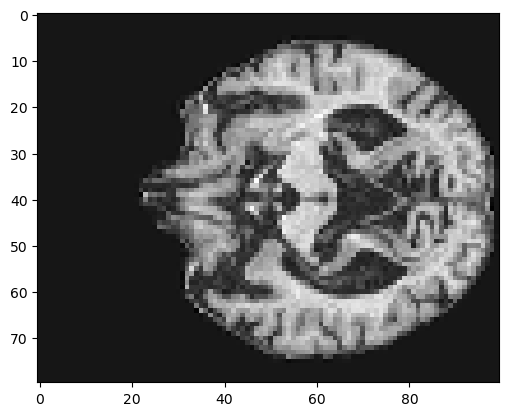

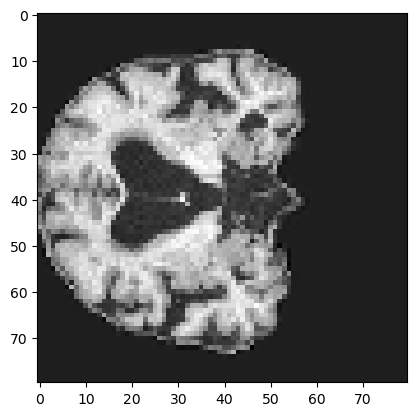

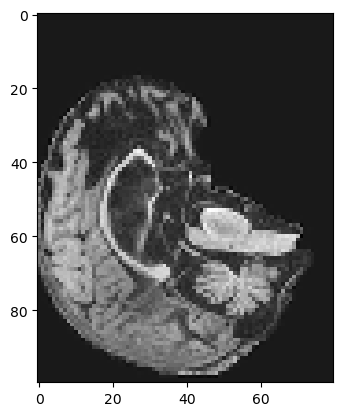

In [36]:
img_prova_idx = 85
img = data_screening[0]["Image"]
print(img.shape)

plt.imshow(img[0][:, :, img.shape[3]//2], cmap='gray')
plt.show()
plt.imshow(img[0][:, img.shape[2]//2, :], cmap='gray')
plt.show()
plt.imshow(img[0][img.shape[1]//2, :, :], cmap='gray')
plt.show()

(1, 64, 104, 80)


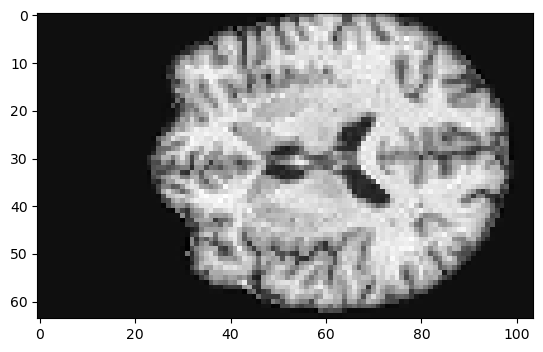

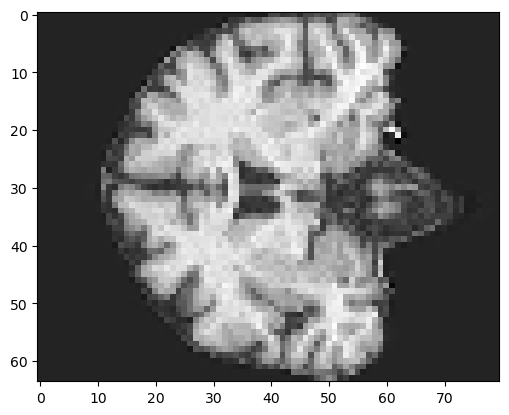

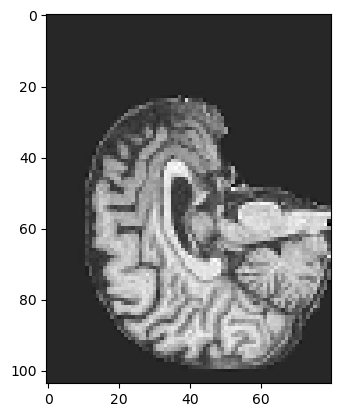

In [30]:
img_prova_idx = 85
img = data_screening[0]["Image"]
print(img.shape)

plt.imshow(img[0][:, :, img.shape[3]//2], cmap='gray')
plt.show()
plt.imshow(img[0][:, img.shape[2]//2, :], cmap='gray')
plt.show()
plt.imshow(img[0][img.shape[1]//2, :, :], cmap='gray')
plt.show()

In [37]:
print(len(data_screening))
print(data_screening[0])

2076
{'Subject': '941_S_1311', 'idImage': 'I97327', 'Age': '69', 'Sex': [0], 'Visit': '3/02/2007', 'ADType': [0, 1, 0], 'Image': array([[[[0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         ...,
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15]],

        [[0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         ...,
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15]],

        [[0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 0.15],
         ...,
         [0.15, 0.15, 0.15, ..., 0.15, 0.15, 

# Analysis

### Analize patients dictionary

In [118]:
from collections import Counter, OrderedDict

def analyze_patients_dictionary2(patients:dict):
    print("Length patients: ", len(patients))
    train_collect = Counter()
    total_visit = 0
    for key in patients.keys():
        if len(patients[key]) <= 1:
            if patients[key]["group"] == "CN": disease = "CN"
            elif patients[key]["group"] == "MCI": disease = "MCI"
            else: disease = "AD"
            train_collect[(patients[key]["sex"], patients[key]["age"], disease)] += 1
            
            total_visit += 1
        else:
            for visit in patients[key]:
                if visit["group"] == "CN": disease = "CN"
                elif visit["group"] == "MCI": disease = "MCI"
                else: disease = "AD"
                train_collect[(visit["sex"], visit["age"], disease)] += 1
                
                total_visit += 1
    print("Total Number of visit: ", total_visit)

    values = list(train_collect.keys())
    print("Max Age: ", max([value[1] for value in values]))
    print("Min Age: ", min([value[1] for value in values]))
    values = [str(i) for i in values]
    counts = train_collect.values()
    
    pprint(train_collect, sort_dicts=True)
    
    # Plotting the histogram
    plt.figure(figsize=(10, 50))
    plt.barh(values, counts, height=0.8, align='center', alpha=0.7)
    plt.xlabel('Values')
    plt.ylabel('Counts')
    plt.title('Histogram from Counter Object')
    plt.show()

Length patients:  639
Total Number of visit:  2077
Max Age:  93
Min Age:  55
Counter({('M', '75', 'MCI'): 43,
         ('M', '74', 'MCI'): 40,
         ('M', '77', 'MCI'): 40,
         ('M', '76', 'MCI'): 38,
         ('M', '80', 'MCI'): 33,
         ('M', '72', 'MCI'): 33,
         ('M', '78', 'MCI'): 32,
         ('M', '73', 'MCI'): 32,
         ('M', '73', 'CN'): 32,
         ('F', '79', 'CN'): 32,
         ('M', '81', 'MCI'): 32,
         ('M', '83', 'MCI'): 31,
         ('F', '74', 'CN'): 30,
         ('M', '74', 'CN'): 30,
         ('M', '76', 'CN'): 29,
         ('M', '84', 'MCI'): 29,
         ('F', '78', 'CN'): 29,
         ('M', '75', 'CN'): 28,
         ('M', '82', 'MCI'): 28,
         ('F', '73', 'CN'): 27,
         ('M', '79', 'MCI'): 27,
         ('F', '80', 'CN'): 27,
         ('F', '75', 'CN'): 26,
         ('M', '77', 'CN'): 25,
         ('M', '85', 'MCI'): 25,
         ('F', '77', 'CN'): 25,
         ('M', '71', 'MCI'): 24,
         ('M', '78', 'CN'): 24,
         ('F

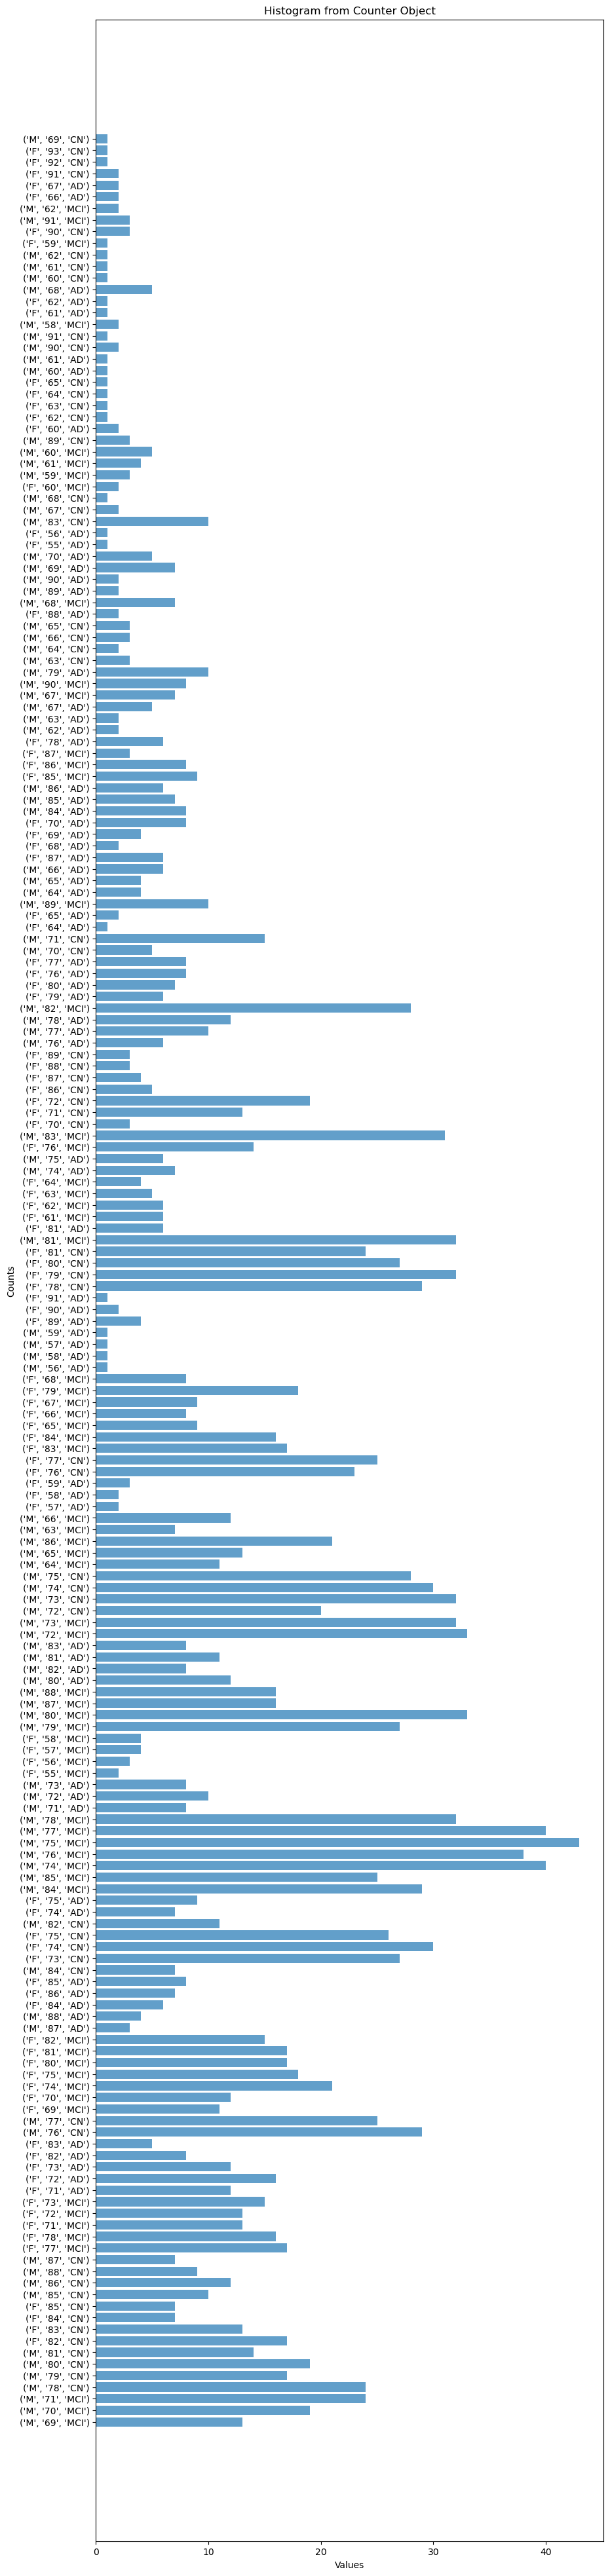

In [114]:
with open(file="/Users/anto/Jupyter/EAI_Napoli/complete_1.json", mode="r") as infile:
    content = json.load(infile)
    # pprint(content)
    analyze_patients_dictionary2(content)


### Save the JSON into .db File

In [38]:
!pwd
!ls
torch.save(data_screening, f"complete_1_1_1_freeSurfer.db") # f"smaller_complete_1_{0}.db"
print("Dataset Correctly Saved")

/Users/anto/Jupyter/EAI_Napoli
SplittedDataset               inspect_data_fsl.ipynb
[0] Primi Spunti interessanti lightning_logs
artifacts                     notebook copie di backup
checkpoints_wandb             notebook.ipynb
complete_1_1_1_fsl.db         patients_1_freeSurfer.json
complete_1_freeSurfer.json    patients_1_fsl.json
complete_1_fsl.json           screening_1_1_1_freeSurfer.db
confusion_matrices            screening_1_1_1_fsl.db
datasets                      screening_1_freeSurfer.json
datasets.zip                  screening_1_fsl.json
experimen results             wandb
inspect_data.ipynb
Dataset Correctly Saved


# Split JSON COMPLETE DATA

In [ ]:
with open(file="/Users/anto/Jupyter/EAI_Napoli/complete_1.json", mode="r") as infile:
    data = json.load(infile)
print("Length of Data: ", len(data))

# Define the number of smaller JSON datasets you want to create
num_smaller_datasets = 36  # Change this as needed
print("Sub-dataset the original data would split to: ", num_smaller_datasets)
# Calculate the number of subjects per smaller dataset
subjects_per_dataset = len(data) // num_smaller_datasets
print("Number of subject per dataset: ", subjects_per_dataset)
print("Median Number of Images in each dataset: ", subjects_per_dataset*4)

# Split the data into smaller datasets
smaller_datasets = [{} for _ in range(num_smaller_datasets)]
print("Length of smaller datasets: ", len(smaller_datasets))
pprint(smaller_datasets)

# current_dataset_index = 0
# subject_count = 0
# for subject, subject_data in data.items():
#     if subject_count != 0 and current_dataset_index !=0:
#         # If the current smaller dataset is full, move to the next one
#         if subject_count>= subjects_per_dataset:
#             current_dataset_index += 1
#             subject_count = 0
#         smaller_datasets[current_dataset_index][subject] = subject_data
#         subject_count += 1
#     else:
#         smaller_datasets[current_dataset_index][subject] = subject_data
#         subject_count += 1
current_dataset_index = 0
subject_count = 0
with tqdm(range(len(data)), desc="Splitting Dataset into Smaller") as pbar:
    for i, subject, subject_data in zip(pbar, data.keys(), data.values()):
        if current_dataset_index < len(smaller_datasets):
            if len(smaller_datasets[current_dataset_index]) <= subjects_per_dataset:
                print(f">| aggiungo dati al subdataset_{current_dataset_index}")
                smaller_datasets[current_dataset_index][subject] = subject_data
            else:
                print(f"#### Length of subdataset_{current_dataset_index}: {len(smaller_datasets[current_dataset_index])} ####")
                print(">>>|| sono qui: CAMBIO DATASET")
                current_dataset_index +=1
                print(f"CURRENT DATASET: {current_dataset_index}")
                smaller_datasets[current_dataset_index][subject] = subject_data
        else:
            print("Pippo")
    print("FINE")
#         # If the current smaller dataset is full, move to the next one
#         if subject_count>= subjects_per_dataset:
#             current_dataset_index += 1
#             subject_count = 0
#         smaller_datasets[current_dataset_index][subject] = subject_data
#         subject_count += 1
#     else:
#         smaller_datasets[current_dataset_index][subject] = subject_data
#         subject_count += 1

In [ ]:
pprint(len(smaller_datasets[35]))

In [ ]:
# Save each smaller dataset as a separate JSON file
for i, smaller_dataset in enumerate(smaller_datasets):
    with open(f'smaller_complete_1_{i}.json', 'w') as f:
        json.dump(smaller_dataset, f, indent=4)